# Advanced Semantic Similarity Search on Netflix Titles

This notebook implements an end-to-end semantic retrieval workflow using Sentence-BERT embeddings, hybrid retrieval, and reranking.

Notebook highlights:
- clean and reproducible preprocessing
- embedding cache for faster reruns
- robust retrieval utilities (semantic, title-based, and hybrid)
- ranking evaluation (Precision@K, Recall@K, MRR, nDCG)
- structured exports to `outputs/` for reporting

## Step 1 - Setup, Data Loading, and Directory Structure

Initialize dependencies, define project paths, create output folders, load the dataset, and build `combined_features` used for retrieval embeddings.

In [19]:
import os
import re
from pathlib import Path
from difflib import get_close_matches

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# STEP 1: Setup, Load Data, and Build Features
DATA_PATH = Path("dataset/netflix_titles.csv")
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
EMBEDDING_PATH = CACHE_DIR / "netflix_all_minilm_embeddings.npy"

# Centralized output folders to keep project root clean
OUTPUT_ROOT = Path("outputs")
OUTPUT_CORE_DIR = OUTPUT_ROOT / "core"
OUTPUT_ADV_DIR = OUTPUT_ROOT / "advanced"
OUTPUT_RECOMMEND_DIR = OUTPUT_ROOT / "recommendation"
OUTPUT_FIG_DIR = OUTPUT_ROOT / "figures"
for p in [OUTPUT_ROOT, OUTPUT_CORE_DIR, OUTPUT_ADV_DIR, OUTPUT_RECOMMEND_DIR, OUTPUT_FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Loading dataset...")
df = pd.read_csv(DATA_PATH)

required_cols = ["title", "listed_in", "description", "type", "release_year", "rating"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Dataset is missing required columns: {missing_required}")

# Fill NA values for stable preprocessing
df["title"] = df["title"].fillna("Unknown")
df["listed_in"] = df["listed_in"].fillna("")
df["description"] = df["description"].fillna("")
df["type"] = df["type"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")

# Build a richer semantic feature string
df["combined_features"] = (
    "Title: " + df["title"] + ". " +
    "Genre: " + df["listed_in"] + ". " +
    "Description: " + df["description"]
)

print(f"Dataset shape: {df.shape}")
print("Output folders ready:")
print(f"- {OUTPUT_CORE_DIR}")
print(f"- {OUTPUT_ADV_DIR}")
print(f"- {OUTPUT_RECOMMEND_DIR}")
print(f"- {OUTPUT_FIG_DIR}")
df[["title", "listed_in", "combined_features"]].head(3)

Loading dataset...
Dataset shape: (8807, 13)
Output folders ready:
- outputs\core
- outputs\advanced
- outputs\recommendation
- outputs\figures


,title,listed_in,combined_features
0,Dick Johnson Is Dead,Documentaries,Title: Dick Johnson Is Dead. Genre: Documentar...
1,Blood & Water,"International TV Shows, TV Dramas, TV Mysteries",Title: Blood & Water. Genre: International TV ...
2,Ganglands,"Crime TV Shows, International TV Shows, TV Act...","Title: Ganglands. Genre: Crime TV Shows, Inter..."


## Step 2 - Initialize Embedding Model

Load the Sentence-BERT model used to encode both dataset records and user queries into dense vectors.

In [2]:
# STEP 2: Initialize Embedding Model
MODEL_NAME = "all-MiniLM-L6-v2"
print(f"Loading Sentence-BERT model: {MODEL_NAME}")
model = SentenceTransformer(MODEL_NAME)

Loading Sentence-BERT model: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Step 3 - Generate or Load Embeddings (Cache Enabled)

Load embeddings from cache when available; otherwise encode all records and save them to disk for faster future runs.

In [3]:
# STEP 3: Generate or Load Embeddings (Cache Enabled)
if EMBEDDING_PATH.exists():
    print(f"Loading embeddings from cache: {EMBEDDING_PATH}")
    document_embeddings = np.load(EMBEDDING_PATH)
else:
    print("Encoding records and creating embedding cache...")
    document_embeddings = model.encode(
        df["combined_features"].tolist(),
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    np.save(EMBEDDING_PATH, document_embeddings)
    print(f"Embeddings saved to: {EMBEDDING_PATH}")

print(f"Embeddings shape: {document_embeddings.shape}")

Loading embeddings from cache: cache\netflix_all_minilm_embeddings.npy
Embeddings shape: (8807, 384)


## Step 4 - Retrieval and Utility Functions

Define reusable utilities for semantic retrieval, fuzzy title matching, and quality checks used in later benchmark steps.

In [5]:
# STEP 4: Define Retrieval and Evaluation Utilities
title_lookup = df["title"].fillna("").astype(str).tolist()
title_lookup_lower = [t.lower() for t in title_lookup]

def _tokenize(text):
    return set(re.findall(r"[a-z0-9]+", text.lower()))

def resolve_title(query, cutoff=0.60):
    key = query.strip().lower()
    if not key:
        return None, "empty"

    if key in title_lookup_lower:
        return key, "exact"

    query_tokens = _tokenize(key)
    best_title = None
    best_score = 0.0

    # Token-overlap strategy improves typo handling better than plain fuzzy matching.
    for candidate in title_lookup_lower:
        cand_tokens = _tokenize(candidate)
        if not cand_tokens:
            continue
        jaccard = len(query_tokens & cand_tokens) / len(query_tokens | cand_tokens) if query_tokens else 0.0
        if jaccard > best_score:
            best_score = jaccard
            best_title = candidate

    if best_title is not None and best_score >= 0.50:
        return best_title, "token_overlap"

    candidates = get_close_matches(key, title_lookup_lower, n=1, cutoff=cutoff)
    if candidates:
        return candidates[0], "approx"
    return None, "not_found"

def semantic_search(
    query,
    df,
    embeddings,
    top_n=5,
    min_score=0.0,
    return_columns=None,
):
    if not isinstance(query, str) or not query.strip():
        raise ValueError("query must be a non-empty string")
    if top_n <= 0:
        raise ValueError("top_n must be greater than 0")

    if return_columns is None:
        return_columns = ["title", "type", "release_year", "rating", "listed_in", "description"]

    query_vector = model.encode([query], convert_to_numpy=True)
    similarity_scores = cosine_similarity(query_vector, embeddings)[0]
    ranked_indices = similarity_scores.argsort()[::-1]

    rows = []
    for idx in ranked_indices:
        score = float(similarity_scores[idx])
        if score < min_score:
            continue

        row = {
            "rank": len(rows) + 1,
            "query": query,
            "similarity_score": round(score, 4),
        }

        for col in return_columns:
            row[col] = df.iloc[idx][col] if col in df.columns else None

        if "description" in row and isinstance(row["description"], str):
            row["description_preview"] = row["description"][:120] + ("..." if len(row["description"]) > 120 else "")

        rows.append(row)
        if len(rows) >= top_n:
            break

    return pd.DataFrame(rows)

def similar_by_title(title_query, df, embeddings, top_n=5, min_score=0.0, cutoff=0.60):
    resolved_key, match_type = resolve_title(title_query, cutoff=cutoff)
    if resolved_key is None:
        return pd.DataFrame({
            "query_input": [title_query],
            "match_type": [match_type],
            "message": ["Title not found. Try another query."],
        })

    original_title = title_lookup[title_lookup_lower.index(resolved_key)]
    result = semantic_search(
        query=original_title,
        df=df,
        embeddings=embeddings,
        top_n=top_n + 1,
        min_score=min_score,
    )

    if not result.empty and "title" in result.columns:
        result = result[result["title"].str.lower() != resolved_key].head(top_n).copy()

    if result.empty:
        return pd.DataFrame({
            "query_input": [title_query],
            "resolved_title": [original_title],
            "match_type": [match_type],
            "message": ["No recommendations found above the score threshold."],
        })

    result.insert(0, "query_input", title_query)
    result.insert(1, "resolved_title", original_title)
    result.insert(2, "match_type", match_type)
    return result.reset_index(drop=True)

def evaluate_semantic_queries(queries, df, embeddings, top_n=5, min_score=0.0):
    eval_rows = []
    results_by_query = {}

    for query in queries:
        rec = semantic_search(query, df, embeddings, top_n=top_n, min_score=min_score)
        results_by_query[query] = rec

        if rec.empty:
            eval_rows.append({
                "query": query,
                "returned_items": 0,
                "avg_score": np.nan,
                "max_score": np.nan,
                "genre_diversity": 0,
            })
            continue

        genres = rec["listed_in"].fillna("").astype(str).str.split(",")
        genre_tokens = {g.strip().lower() for items in genres for g in items if g.strip()}

        eval_rows.append({
            "query": query,
            "returned_items": len(rec),
            "avg_score": round(float(rec["similarity_score"].mean()), 4),
            "max_score": round(float(rec["similarity_score"].max()), 4),
            "genre_diversity": len(genre_tokens),
        })

    return pd.DataFrame(eval_rows), results_by_query

def pairwise_overlap(results_by_query):
    queries = list(results_by_query.keys())
    overlap_rows = []
    for i in range(len(queries)):
        for j in range(i + 1, len(queries)):
            q1, q2 = queries[i], queries[j]
            s1 = set(results_by_query[q1].get("title", pd.Series(dtype=str)).astype(str))
            s2 = set(results_by_query[q2].get("title", pd.Series(dtype=str)).astype(str))

            denom = max(1, min(len(s1), len(s2)))
            ratio = len(s1.intersection(s2)) / denom
            overlap_rows.append({
                "query_a": q1,
                "query_b": q2,
                "overlap_count": len(s1.intersection(s2)),
                "overlap_ratio": round(ratio, 4),
            })

    return pd.DataFrame(overlap_rows)

## Step 5 - Baseline Benchmarks and Core Exports

Run baseline semantic and title-based queries, compute summary diagnostics, and export core results to `outputs/core`.

In [20]:
# STEP 5: Run Benchmarks and Export Outputs
semantic_queries = [
    "dark magic and fantasy world",
    "investigating a serial killer",
    "funny stand up comedy",
    "slow emotional romance",
    "political crime thriller"
]

title_queries = ["Narcos", "The Crowm", "Money Heist"]

# 1) Run semantic-query retrieval
all_semantic_results = []
for q in semantic_queries:
    rec = semantic_search(
        query=q,
        df=df,
        embeddings=document_embeddings,
        top_n=5,
        min_score=0.20,
    )
    all_semantic_results.append(rec)
    print("=" * 80)
    print(f"Semantic query: {q}")
    display(rec[["rank", "title", "similarity_score", "listed_in", "description_preview"]].head(5))

semantic_results_df = pd.concat(all_semantic_results, ignore_index=True) if all_semantic_results else pd.DataFrame()

# 2) Run flexible title-based retrieval
all_title_results = []
for tq in title_queries:
    t_rec = similar_by_title(
        title_query=tq,
        df=df,
        embeddings=document_embeddings,
        top_n=5,
        min_score=0.20,
        cutoff=0.55,
    )
    all_title_results.append(t_rec)
    print("=" * 80)
    print(f"Title query: {tq}")
    display(t_rec.head(5))

title_results_df = pd.concat(all_title_results, ignore_index=True) if all_title_results else pd.DataFrame()

# 3) Evaluate semantic-query quality metrics
eval_df, results_map = evaluate_semantic_queries(
    queries=semantic_queries,
    df=df,
    embeddings=document_embeddings,
    top_n=5,
    min_score=0.20,
 )
overlap_df = pairwise_overlap(results_map)

print("\nEvaluation summary:")
display(eval_df)
print("\nPairwise overlap between query result sets:")
display(overlap_df)

# 4) Export outputs
semantic_results_path = OUTPUT_CORE_DIR / "semantic_query_results.csv"
title_results_path = OUTPUT_CORE_DIR / "title_query_results.csv"
eval_results_path = OUTPUT_CORE_DIR / "semantic_evaluation_summary.csv"
overlap_results_path = OUTPUT_CORE_DIR / "semantic_pairwise_overlap.csv"

if not semantic_results_df.empty:
    semantic_results_df.to_csv(semantic_results_path, index=False)
if not title_results_df.empty:
    title_results_df.to_csv(title_results_path, index=False)
if not eval_df.empty:
    eval_df.to_csv(eval_results_path, index=False)
if not overlap_df.empty:
    overlap_df.to_csv(overlap_results_path, index=False)

print("\nSaved files:")
print(f"- {semantic_results_path}")
print(f"- {title_results_path}")
print(f"- {eval_results_path}")
print(f"- {overlap_results_path}")

Semantic query: dark magic and fantasy world


,rank,title,similarity_score,listed_in,description_preview
0,1,Shadow,0.5170,"Action & Adventure, Dramas, International Movies",As three kingdoms struggle for control of a wa...
1,2,Light in the Dark,0.5047,"Dramas, International Movies",A terrifying home invasion shatters a couple's...
2,3,The Magicians,0.5020,"TV Dramas, TV Sci-Fi & Fantasy",When grad student Quentin Coldwater enters a c...
3,4,Nightbooks,0.4969,Children & Family Movies,Scary story fan Alex must tell a spine-tinglin...
4,5,The Crystal Calls Making the Dark Crystal: Age...,0.4889,"Documentaries, International Movies","Go behind the scenes with stars, puppeteers an..."


Semantic query: investigating a serial killer


,rank,title,similarity_score,listed_in,description_preview
0,1,Inside the Mind of a Serial Killer,0.5663,"Crime TV Shows, Docuseries",Mixing dramatic re-enactments with real-life f...
1,2,The Investigator: A British Crime Story,0.5466,"British TV Shows, Crime TV Shows, Docuseries","After 40 years of inconclusive evidence, renow..."
2,3,The Murder Detectives,0.5318,"British TV Shows, Crime TV Shows, Docuseries",This series tracks the ups and downs of an 18-...
3,4,I AM A KILLER: RELEASED,0.5271,"British TV Shows, Crime TV Shows, Docuseries","In this crime docuseries spinoff, a convict is..."
4,5,Forensic,0.5212,"International Movies, Thrillers",A pair of officers with history navigates clue...


Semantic query: funny stand up comedy


...


Evaluation summary:


,query,returned_items,avg_score,max_score,genre_diversity
0,dark magic and fantasy world,5,0.5019,0.5170,7
1,investigating a serial killer,5,0.5386,0.5663,5
2,funny stand up comedy,5,0.6159,0.6412,3
3,slow emotional romance,5,0.5486,0.5842,8
4,political crime thriller,5,0.5871,0.5964,7



Pairwise overlap between query result sets:


,query_a,query_b,overlap_count,overlap_ratio
0,dark magic and fantasy world,investigating a serial killer,0,0.0
1,dark magic and fantasy world,funny stand up comedy,0,0.0
2,dark magic and fantasy world,slow emotional romance,0,0.0
3,dark magic and fantasy world,political crime thriller,0,0.0
4,investigating a serial killer,funny stand up comedy,0,0.0
5,investigating a serial killer,slow emotional romance,0,0.0
6,investigating a serial killer,political crime thriller,0,0.0
7,funny stand up comedy,slow emotional romance,0,0.0
8,funny stand up comedy,political crime thriller,0,0.0
9,slow emotional romance,political crime thriller,0,0.0



Saved files:
- outputs\core\semantic_query_results.csv
- outputs\core\title_query_results.csv
- outputs\core\semantic_evaluation_summary.csv
- outputs\core\semantic_pairwise_overlap.csv


## Step 6 - Accuracy Upgrade: Normalization, Hybrid Retrieval, and Filters

Improve retrieval quality with query normalization, alias-aware title resolution, weighted dense features, TF-IDF lexical features, and metadata filtering.

In [11]:
# STEP 6: Accuracy Upgrade Utilities
import re
from sentence_transformers import CrossEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import minmax_scale

# 1) Query normalization
def normalize_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-z0-9\s&]", "", text)
    return text

# 2) Alias-aware title map (you can keep expanding this)
TITLE_ALIAS_MAP = {
    "money heist": "money heist from tokyo to berlin",
    "la casa de papel": "money heist from tokyo to berlin",
    "the crownn": "the crown",
    "narkos": "narcos",
}

normalized_title_lookup = [normalize_text(t) for t in title_lookup]

def resolve_title_v2(query, cutoff=0.60):
    key = normalize_text(query)
    if not key:
        return None, "empty"

    if key in TITLE_ALIAS_MAP:
        alias_key = normalize_text(TITLE_ALIAS_MAP[key])
        if alias_key in normalized_title_lookup:
            return alias_key, "alias"

    if key in normalized_title_lookup:
        return key, "exact"

    query_tokens = set(key.split())
    best_title = None
    best_score = 0.0

    for candidate in normalized_title_lookup:
        cand_tokens = set(candidate.split())
        if not cand_tokens:
            continue
        jaccard = len(query_tokens & cand_tokens) / len(query_tokens | cand_tokens) if query_tokens else 0.0
        if jaccard > best_score:
            best_score = jaccard
            best_title = candidate

    if best_title is not None and best_score >= 0.50:
        return best_title, "token_overlap"

    candidates = get_close_matches(key, normalized_title_lookup, n=1, cutoff=cutoff)
    if candidates:
        return candidates[0], "approx"

    return None, "not_found"

# 3) Weighted feature variant for stronger semantic signal
df_weighted = df.copy()
df_weighted["combined_features_weighted"] = (
    ("Title: " + df_weighted["title"] + ". ") * 3
    + ("Genre: " + df_weighted["listed_in"] + ". ") * 2
    + ("Description: " + df_weighted["description"])
)

WEIGHTED_EMBEDDING_PATH = CACHE_DIR / "netflix_all_minilm_embeddings_weighted.npy"

if WEIGHTED_EMBEDDING_PATH.exists():
    weighted_embeddings = np.load(WEIGHTED_EMBEDDING_PATH)
else:
    weighted_embeddings = model.encode(
        df_weighted["combined_features_weighted"].tolist(),
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    np.save(WEIGHTED_EMBEDDING_PATH, weighted_embeddings)

# 4) Lexical baseline (TF-IDF) for hybrid retrieval
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=50000,
 )
tfidf_matrix = tfidf_vectorizer.fit_transform(df["combined_features"].fillna(""))

# 5) Filterable semantic search
def semantic_search_v2(
    query,
    df,
    embeddings,
    top_n=5,
    min_score=0.0,
    content_type="All",
    year_min=None,
    year_max=None,
    return_columns=None,
 ):
    normalized_query = normalize_text(query)
    if not normalized_query:
        raise ValueError("query must be a non-empty string")

    if return_columns is None:
        return_columns = ["title", "type", "release_year", "rating", "listed_in", "description"]

    query_vector = model.encode([normalized_query], convert_to_numpy=True)
    similarity_scores = cosine_similarity(query_vector, embeddings)[0]
    ranked_indices = similarity_scores.argsort()[::-1]

    rows = []
    for idx in ranked_indices:
        score = float(similarity_scores[idx])
        if score < min_score:
            continue

        row_type = str(df.iloc[idx]["type"]) if "type" in df.columns else "Unknown"
        row_year = df.iloc[idx]["release_year"] if "release_year" in df.columns else None

        if content_type != "All" and row_type != content_type:
            continue
        if year_min is not None and pd.notna(row_year) and int(row_year) < int(year_min):
            continue
        if year_max is not None and pd.notna(row_year) and int(row_year) > int(year_max):
            continue

        row = {
            "rank": len(rows) + 1,
            "query": query,
            "similarity_score": round(score, 4),
        }
        for col in return_columns:
            row[col] = df.iloc[idx][col] if col in df.columns else None

        rows.append(row)
        if len(rows) >= top_n:
            break

    return pd.DataFrame(rows)

# 6) Hybrid retrieval: dense + lexical fusion
def hybrid_search_v2(
    query,
    df,
    embeddings,
    top_n=5,
    min_score=0.0,
    content_type="All",
    year_min=None,
    year_max=None,
    return_columns=None,
    dense_weight=0.65,
    lexical_weight=0.35,
 ):
    normalized_query = normalize_text(query)
    if not normalized_query:
        raise ValueError("query must be a non-empty string")

    if return_columns is None:
        return_columns = ["title", "type", "release_year", "rating", "listed_in", "description"]

    query_dense = model.encode([normalized_query], convert_to_numpy=True)
    dense_scores = cosine_similarity(query_dense, embeddings)[0]

    query_tfidf = tfidf_vectorizer.transform([normalized_query])
    lexical_scores = cosine_similarity(query_tfidf, tfidf_matrix).ravel()

    dense_norm = minmax_scale(dense_scores)
    lexical_norm = minmax_scale(lexical_scores)
    hybrid_scores = (dense_weight * dense_norm) + (lexical_weight * lexical_norm)

    ranked_indices = hybrid_scores.argsort()[::-1]

    rows = []
    for idx in ranked_indices:
        score = float(hybrid_scores[idx])
        if score < min_score:
            continue

        row_type = str(df.iloc[idx]["type"]) if "type" in df.columns else "Unknown"
        row_year = df.iloc[idx]["release_year"] if "release_year" in df.columns else None

        if content_type != "All" and row_type != content_type:
            continue
        if year_min is not None and pd.notna(row_year) and int(row_year) < int(year_min):
            continue
        if year_max is not None and pd.notna(row_year) and int(row_year) > int(year_max):
            continue

        row = {
            "rank": len(rows) + 1,
            "query": query,
            "similarity_score": round(score, 4),
            "dense_score": round(float(dense_norm[idx]), 4),
            "lexical_score": round(float(lexical_norm[idx]), 4),
        }
        for col in return_columns:
            row[col] = df.iloc[idx][col] if col in df.columns else None

        rows.append(row)
        if len(rows) >= top_n:
            break

    return pd.DataFrame(rows)

print("Step 6 utilities are ready.")
print(f"Weighted embeddings shape: {weighted_embeddings.shape}")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

Step 6 utilities are ready.
Weighted embeddings shape: (8807, 384)
TF-IDF matrix shape: (8807, 23186)


## Step 7 - Ranking Evaluation Metrics

Evaluate multiple retrieval configurations using ranking metrics: Precision@K, Recall@K, MRR@K, and nDCG@K.

In [12]:
# STEP 7: Precision@K + Recall@K + MRR + nDCG Evaluation
def proxy_relevance_labels(query, result_df):
    if result_df.empty:
        return []
    labels = []
    for _, row in result_df.iterrows():
        q_tokens = set(normalize_text(query).split())
        text_blob = f"{row.get('listed_in', '')} {row.get('description', '')}"
        d_tokens = set(normalize_text(text_blob).split())
        overlap = len(q_tokens & d_tokens) if q_tokens and d_tokens else 0
        labels.append(1 if overlap >= 1 else 0)
    return labels

def precision_at_k_from_labels(labels, k=5):
    if not labels:
        return 0.0
    topk = labels[:k]
    return float(np.mean(topk)) if topk else 0.0

def recall_at_k_from_labels(labels, total_relevant, k=5):
    if total_relevant <= 0:
        return 0.0
    topk_rel = int(np.sum(labels[:k]))
    return float(topk_rel / total_relevant)

def mrr_at_k_from_labels(labels, k=5):
    for i, rel in enumerate(labels[:k], start=1):
        if rel == 1:
            return 1.0 / i
    return 0.0

def ndcg_at_k_from_labels(labels, k=5):
    topk = labels[:k]
    if not topk:
        return 0.0

    dcg = 0.0
    for i, rel in enumerate(topk, start=1):
        dcg += (2**rel - 1) / np.log2(i + 1)

    ideal = sorted(topk, reverse=True)
    idcg = 0.0
    for i, rel in enumerate(ideal, start=1):
        idcg += (2**rel - 1) / np.log2(i + 1)

    return float(dcg / idcg) if idcg > 0 else 0.0

def evaluate_ranking_metrics(
    queries,
    search_fn,
    df,
    embeddings,
    k=5,
    min_score=0.2,
    content_type="All",
    recall_pool_n=100,
    config_name="model",
):
    rows = []
    for q in queries:
        topk_df = search_fn(
            query=q,
            df=df,
            embeddings=embeddings,
            top_n=k,
            min_score=min_score,
            content_type=content_type,
        )
        topk_labels = proxy_relevance_labels(q, topk_df)

        pool_df = search_fn(
            query=q,
            df=df,
            embeddings=embeddings,
            top_n=recall_pool_n,
            min_score=0.0,
            content_type=content_type,
        )
        pool_labels = proxy_relevance_labels(q, pool_df)
        total_relevant_pool = int(np.sum(pool_labels))

        rows.append({
            "config": config_name,
            "query": q,
            "k": k,
            "precision_at_k": round(precision_at_k_from_labels(topk_labels, k), 4),
            "recall_at_k": round(recall_at_k_from_labels(topk_labels, total_relevant_pool, k), 4),
            "mrr_at_k": round(mrr_at_k_from_labels(topk_labels, k), 4),
            "ndcg_at_k": round(ndcg_at_k_from_labels(topk_labels, k), 4),
            "avg_similarity_topk": round(float(topk_df["similarity_score"].mean()), 4) if not topk_df.empty else np.nan,
            "relevant_in_pool": total_relevant_pool,
        })

    return pd.DataFrame(rows)

eval_default = evaluate_ranking_metrics(
    queries=semantic_queries,
    search_fn=semantic_search_v2,
    df=df,
    embeddings=document_embeddings,
    k=5,
    min_score=0.20,
    content_type="All",
    config_name="dense_default",
)

eval_weighted = evaluate_ranking_metrics(
    queries=semantic_queries,
    search_fn=semantic_search_v2,
    df=df,
    embeddings=weighted_embeddings,
    k=5,
    min_score=0.20,
    content_type="All",
    config_name="dense_weighted",
)

eval_hybrid = evaluate_ranking_metrics(
    queries=semantic_queries,
    search_fn=hybrid_search_v2,
    df=df,
    embeddings=document_embeddings,
    k=5,
    min_score=0.20,
    content_type="All",
    config_name="hybrid_dense_lexical",
)

all_eval_metrics = pd.concat([eval_default, eval_weighted, eval_hybrid], ignore_index=True)
summary_metrics = (
    all_eval_metrics.groupby("config")[["precision_at_k", "recall_at_k", "mrr_at_k", "ndcg_at_k", "avg_similarity_topk"]]
    .mean()
    .round(4)
    .reset_index()
    .sort_values(by=["ndcg_at_k", "mrr_at_k"], ascending=False)
    .reset_index(drop=True)
)

comparison_precision = eval_default[["query", "precision_at_k"]].merge(
    eval_weighted[["query", "precision_at_k"]],
    on="query",
    suffixes=("_default", "_weighted"),
)

print("Per-query ranking metrics across all configurations:")
display(all_eval_metrics)
print("\nAverage metrics by configuration:")
display(summary_metrics)
print("\nPrecision@5 comparison (default vs weighted):")
display(comparison_precision)

Per-query ranking metrics across all configurations:


,config,query,k,precision_at_k,recall_at_k,mrr_at_k,ndcg_at_k,avg_similarity_topk,relevant_in_pool
0,dense_default,dark magic and fantasy world,5,0.6,0.0390,0.5,0.7123,0.5019,77
1,dense_default,investigating a serial killer,5,0.8,0.0449,1.0,0.9558,0.5386,89
2,dense_default,funny stand up comedy,5,1.0,0.0505,1.0,1.0000,0.6159,99
3,dense_default,slow emotional romance,5,0.6,0.3333,0.5,0.7123,0.5486,9
4,dense_default,political crime thriller,5,0.6,0.0857,1.0,1.0000,0.5871,35
5,dense_weighted,dark magic and fantasy world,5,0.6,0.0395,0.5,0.7328,0.4819,76
6,dense_weighted,investigating a serial killer,5,0.8,0.0476,1.0,0.9829,0.4862,84
7,dense_weighted,funny stand up comedy,5,1.0,0.0510,1.0,1.0000,0.5792,98
8,dense_weighted,slow emotional romance,5,0.6,0.2727,1.0,0.9675,0.4845,11
9,dense_weighted,political crime thriller,5,0.6,0.0789,1.0,1.0000,0.5402,38



Average metrics by configuration:


,config,precision_at_k,recall_at_k,mrr_at_k,ndcg_at_k,avg_similarity_topk
0,dense_weighted,0.72,0.0979,0.9,0.9366,0.5144
1,hybrid_dense_lexical,0.92,0.0560,0.9,0.9359,0.8256
2,dense_default,0.72,0.1107,0.8,0.8761,0.5584



Precision@5 comparison (default vs weighted):


,query,precision_at_k_default,precision_at_k_weighted
0,dark magic and fantasy world,0.6,0.6
1,investigating a serial killer,0.8,0.8
2,funny stand up comedy,1.0,1.0
3,slow emotional romance,0.6,0.6
4,political crime thriller,0.6,0.6


## Step 8 - Ablation and Two-Stage Re-ranking

Run optional ablation experiments and demonstrate two-stage retrieval:
- Stage 1: candidate retrieval (bi-encoder)
- Stage 2: reranking (cross-encoder)

In [13]:
# STEP 8: Ablation + Optional CrossEncoder Re-ranking
import os
from transformers.utils import logging as hf_logging

# Hide symlink warning on Windows and reduce transformer loading logs
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
hf_logging.set_verbosity_error()

ADV_MODEL_CONFIGS = [
    {"name": "MiniLM-default", "model_name": "all-MiniLM-L6-v2", "feature_col": "combined_features", "cache": CACHE_DIR / "ablation_minilm_default.npy"},
    {"name": "MiniLM-weighted", "model_name": "all-MiniLM-L6-v2", "feature_col": "combined_features_weighted", "cache": CACHE_DIR / "ablation_minilm_weighted.npy"},
    {"name": "MPNet-default", "model_name": "all-mpnet-base-v2", "feature_col": "combined_features", "cache": CACHE_DIR / "ablation_mpnet_default.npy"},
]

def get_embeddings_for_config(df_source, cfg):
    cache_path = cfg["cache"]
    if cache_path.exists():
        return np.load(cache_path)

    local_model = SentenceTransformer(cfg["model_name"])
    emb = local_model.encode(
        df_source[cfg["feature_col"]].tolist(),
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    np.save(cache_path, emb)
    return emb

def crossencoder_rerank(
    query,
    base_results_df,
    final_top_k=10,
    rerank_model_name="cross-encoder/ms-marco-MiniLM-L-6-v2",
    ce_model=None,
):
    if base_results_df.empty:
        return base_results_df

    ce = ce_model
    if ce is None:
        try:
            ce = CrossEncoder(rerank_model_name)
        except Exception as exc:
            print(f"CrossEncoder failed to load: {exc}")
            print("Falling back to bi-encoder ranking only.")
            fallback = base_results_df.copy().head(final_top_k).reset_index(drop=True)
            fallback["crossencoder_score"] = np.nan
            fallback["rank"] = np.arange(1, len(fallback) + 1)
            return fallback

    candidate_texts = (
        base_results_df["title"].fillna("") + " . " +
        base_results_df["listed_in"].fillna("") + " . " +
        base_results_df["description"].fillna("")
    ).tolist()

    pairs = [[query, c] for c in candidate_texts]
    ce_scores = ce.predict(pairs)

    reranked = base_results_df.copy().reset_index(drop=True)
    reranked["crossencoder_score"] = ce_scores
    reranked = reranked.sort_values("crossencoder_score", ascending=False).head(final_top_k).reset_index(drop=True)
    reranked["rank"] = np.arange(1, len(reranked) + 1)
    return reranked

RUN_HEAVY_ABLATION = False
if RUN_HEAVY_ABLATION:
    ablation_rows = []
    for cfg in ADV_MODEL_CONFIGS:
        emb = get_embeddings_for_config(df_weighted if cfg["feature_col"] == "combined_features_weighted" else df, cfg)
        eval_df_cfg = evaluate_ranking_metrics(
            queries=semantic_queries,
            search_fn=semantic_search_v2,
            df=df_weighted if cfg["feature_col"] == "combined_features_weighted" else df,
            embeddings=emb,
            k=5,
            min_score=0.20,
            content_type="All",
            config_name=cfg["name"],
        )
        ablation_rows.append({
            "config": cfg["name"],
            "mean_precision_at_5": round(float(eval_df_cfg["precision_at_k"].mean()), 4),
            "mean_mrr_at_5": round(float(eval_df_cfg["mrr_at_k"].mean()), 4),
            "mean_ndcg_at_5": round(float(eval_df_cfg["ndcg_at_k"].mean()), 4),
        })

    ablation_summary_df = pd.DataFrame(ablation_rows)
    print("Ablation summary:")
    display(ablation_summary_df)
else:
    print("Heavy ablation is skipped by default.")
    print("Set RUN_HEAVY_ABLATION = True to run MiniLM vs MPNet comparison.")

# Two-stage retrieval + reranking demo
RETRIEVAL_TOP_N = 50
FINAL_TOP_K = 10
RERANK_MODEL_NAME = "cross-encoder/ms-marco-MiniLM-L-6-v2"

shared_ce_model = None
try:
    shared_ce_model = CrossEncoder(RERANK_MODEL_NAME)
except Exception as exc:
    print(f"Could not preload CrossEncoder ({RERANK_MODEL_NAME}): {exc}")
    print("Demo/evaluation will use fallback bi-encoder ranking.")

demo_query = semantic_queries[0]
base_candidates = semantic_search_v2(
    query=demo_query,
    df=df,
    embeddings=document_embeddings,
    top_n=RETRIEVAL_TOP_N,
    min_score=0.20,
)
reranked_final = crossencoder_rerank(
    query=demo_query,
    base_results_df=base_candidates,
    final_top_k=FINAL_TOP_K,
    ce_model=shared_ce_model,
)

print(f"Two-stage retrieval demo for query: {demo_query}")
print(f"Stage 1 (bi-encoder) candidates: top {RETRIEVAL_TOP_N}")
print(f"Stage 2 (cross-encoder) final: top {FINAL_TOP_K}")

before_view = base_candidates[["rank", "title", "similarity_score", "listed_in"]].head(FINAL_TOP_K).copy()
before_view = before_view.rename(columns={"rank": "rank_before"})

after_view = reranked_final[["rank", "title", "similarity_score", "crossencoder_score", "listed_in"]].copy()
after_view = after_view.rename(columns={"rank": "rank_after"})

comparison_rerank = after_view.merge(
    before_view[["title", "rank_before"]],
    on="title",
    how="left",
)
comparison_rerank["delta_rank"] = comparison_rerank["rank_before"] - comparison_rerank["rank_after"]
comparison_rerank["promoted_from_below_top10"] = comparison_rerank["rank_before"].isna()
comparison_rerank = comparison_rerank[[
    "rank_before",
    "rank_after",
    "delta_rank",
    "promoted_from_below_top10",
    "title",
    "similarity_score",
    "crossencoder_score",
    "listed_in",
]]

print("Top-K before vs after reranking:")
display(comparison_rerank)

# Multi-query reranking stability check
rerank_eval_rows = []
for q in semantic_queries:
    base_q = semantic_search_v2(
        query=q,
        df=df,
        embeddings=document_embeddings,
        top_n=RETRIEVAL_TOP_N,
        min_score=0.20,
    )
    reranked_q = crossencoder_rerank(
        query=q,
        base_results_df=base_q,
        final_top_k=FINAL_TOP_K,
        ce_model=shared_ce_model,
    )

    before_q = base_q[["rank", "title"]].head(FINAL_TOP_K).rename(columns={"rank": "rank_before"})
    after_q = reranked_q[["rank", "title"]].rename(columns={"rank": "rank_after"})

    cmp_q = after_q.merge(before_q, on="title", how="left")
    cmp_q["delta_rank"] = cmp_q["rank_before"] - cmp_q["rank_after"]

    promoted = int(cmp_q["rank_before"].isna().sum())
    moved_up = int((cmp_q["delta_rank"] > 0).sum())
    moved_down = int((cmp_q["delta_rank"] < 0).sum())
    unchanged = int((cmp_q["delta_rank"] == 0).sum())

    avg_delta = np.nan
    if cmp_q["delta_rank"].notna().any():
        avg_delta = round(float(cmp_q["delta_rank"].dropna().mean()), 4)

    rerank_eval_rows.append({
        "query": q,
        "promoted_into_top10": promoted,
        "moved_up_count": moved_up,
        "moved_down_count": moved_down,
        "unchanged_count": unchanged,
        "avg_delta_rank_non_nan": avg_delta,
    })

rerank_summary_df = pd.DataFrame(rerank_eval_rows)
overall_rerank_summary = {
    "avg_promoted_into_top10": round(float(rerank_summary_df["promoted_into_top10"].mean()), 4),
    "avg_moved_up_count": round(float(rerank_summary_df["moved_up_count"].mean()), 4),
    "avg_moved_down_count": round(float(rerank_summary_df["moved_down_count"].mean()), 4),
}

print("\nReranking stability across semantic queries:")
display(rerank_summary_df)
print("\nOverall reranking averages:")
display(pd.DataFrame([overall_rerank_summary]))

Heavy ablation is skipped by default.
Set RUN_HEAVY_ABLATION = True to run MiniLM vs MPNet comparison.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Two-stage retrieval demo for query: dark magic and fantasy world
Stage 1 (bi-encoder) candidates: top 50
Stage 2 (cross-encoder) final: top 10
Top-K before vs after reranking:


,rank_before,rank_after,delta_rank,promoted_from_below_top10,title,similarity_score,crossencoder_score,listed_in
0,5.0,1,4.0,False,The Crystal Calls Making the Dark Crystal: Age...,0.4889,2.557966,"Documentaries, International Movies"
1,3.0,2,1.0,False,The Magicians,0.5020,1.993115,"TV Dramas, TV Sci-Fi & Fantasy"
2,NaN,3,NaN,True,The Dark Crystal: Age of Resistance,0.4530,0.698827,"TV Action & Adventure, TV Dramas, TV Sci-Fi & ..."
3,10.0,4,6.0,False,Dark Light,0.4763,0.498801,"Horror Movies, Independent Movies, Sci-Fi & Fa..."
4,NaN,5,NaN,True,Black Mirror: Bandersnatch,0.4403,0.318127,"Dramas, International Movies, Sci-Fi & Fantasy"
5,NaN,6,NaN,True,Shadow and Bone,0.4605,-0.290654,"TV Action & Adventure, TV Dramas, TV Sci-Fi & ..."
6,8.0,7,1.0,False,PILI Fantasy: War of Dragons,0.4821,-0.884687,"International TV Shows, TV Action & Adventure,..."
7,NaN,8,NaN,True,Maharakshak Devi,0.4401,-1.738631,"International TV Shows, TV Action & Adventure,..."
8,7.0,9,-2.0,False,P,0.4840,-1.750071,"Horror Movies, International Movies"
9,NaN,10,NaN,True,Creeped Out,0.4351,-1.778613,"British TV Shows, Kids' TV, TV Thrillers"



Reranking stability across semantic queries:


,query,promoted_into_top10,moved_up_count,moved_down_count,unchanged_count,avg_delta_rank_non_nan
0,dark magic and fantasy world,5,4,1,0,2.0000
1,investigating a serial killer,7,1,2,0,-0.6667
2,funny stand up comedy,7,0,3,0,-4.6667
3,slow emotional romance,5,1,3,1,-1.6000
4,political crime thriller,5,2,2,1,-1.4000



Overall reranking averages:


,avg_promoted_into_top10,avg_moved_up_count,avg_moved_down_count
0,5.8,1.6,2.2


### Step 8 Interpretation - Before vs After Reranking

How to read the reranking table:
- `rank_before`: position in Stage 1 top list
- `rank_after`: position after Stage 2 reranking
- `rank_before = NaN`: item was outside initial top-10, then promoted into final top-10
- positive `delta_rank`: moved up after reranking
- negative `delta_rank`: moved down after reranking

Use this table together with Step 7 metrics for both qualitative and quantitative validation.

## Step 9 - Export Advanced Metrics and Auto Insights

Export advanced evaluation outputs to `outputs/advanced` and generate concise insight summaries for reporting.

In [21]:
# STEP 9: Export Advanced Metrics and Auto Insights
advanced_export_paths = {
    "ranking_metrics_per_query": OUTPUT_ADV_DIR / "ranking_metrics_per_query.csv",
    "ranking_metrics_summary": OUTPUT_ADV_DIR / "ranking_metrics_summary.csv",
    "rerank_stability_per_query": OUTPUT_ADV_DIR / "rerank_stability_per_query.csv",
    "rerank_overall_summary": OUTPUT_ADV_DIR / "rerank_overall_summary.csv",
}

# Export advanced evaluation tables
all_eval_metrics.to_csv(advanced_export_paths["ranking_metrics_per_query"], index=False)
summary_metrics.to_csv(advanced_export_paths["ranking_metrics_summary"], index=False)
rerank_summary_df.to_csv(advanced_export_paths["rerank_stability_per_query"], index=False)
pd.DataFrame([overall_rerank_summary]).to_csv(advanced_export_paths["rerank_overall_summary"], index=False)

# Auto insights for quick interpretation
best_ndcg_row = summary_metrics.sort_values("ndcg_at_k", ascending=False).iloc[0]
best_mrr_row = summary_metrics.sort_values("mrr_at_k", ascending=False).iloc[0]
best_precision_row = summary_metrics.sort_values("precision_at_k", ascending=False).iloc[0]

hardest_query = (
    all_eval_metrics.groupby("query")["ndcg_at_k"]
    .mean()
    .sort_values(ascending=True)
    .index[0]
)

easiest_query = (
    all_eval_metrics.groupby("query")["ndcg_at_k"]
    .mean()
    .sort_values(ascending=False)
    .index[0]
)

insights_rows = [
    {"insight": "Best config by nDCG@K", "value": f"{best_ndcg_row['config']} ({best_ndcg_row['ndcg_at_k']})"},
    {"insight": "Best config by MRR@K", "value": f"{best_mrr_row['config']} ({best_mrr_row['mrr_at_k']})"},
    {"insight": "Best config by Precision@K", "value": f"{best_precision_row['config']} ({best_precision_row['precision_at_k']})"},
    {"insight": "Hardest query (lowest mean nDCG)", "value": hardest_query},
    {"insight": "Easiest query (highest mean nDCG)", "value": easiest_query},
    {"insight": "Avg promoted into top-10 after rerank", "value": overall_rerank_summary['avg_promoted_into_top10']},
    {"insight": "Avg moved up after rerank", "value": overall_rerank_summary['avg_moved_up_count']},
    {"insight": "Avg moved down after rerank", "value": overall_rerank_summary['avg_moved_down_count']},
]
insights_df = pd.DataFrame(insights_rows)

print("Advanced metric files saved:")
for k, v in advanced_export_paths.items():
    print(f"- {k}: {v}")

print("\nAuto insights summary:")
display(insights_df)

Advanced metric files saved:
- ranking_metrics_per_query: outputs\advanced\ranking_metrics_per_query.csv
- ranking_metrics_summary: outputs\advanced\ranking_metrics_summary.csv
- rerank_stability_per_query: outputs\advanced\rerank_stability_per_query.csv
- rerank_overall_summary: outputs\advanced\rerank_overall_summary.csv

Auto insights summary:


,insight,value
0,Best config by nDCG@K,dense_weighted (0.9366)
1,Best config by MRR@K,dense_weighted (0.9)
2,Best config by Precision@K,hybrid_dense_lexical (0.92)
3,Hardest query (lowest mean nDCG),slow emotional romance
4,Easiest query (highest mean nDCG),funny stand up comedy
5,Avg promoted into top-10 after rerank,5.8
6,Avg moved up after rerank,1.6
7,Avg moved down after rerank,2.2


## Step 10 - Visualization Dashboard

Visualize configuration-level metrics, query-level nDCG, and reranking movement.
All generated figures are saved to `outputs/figures`.

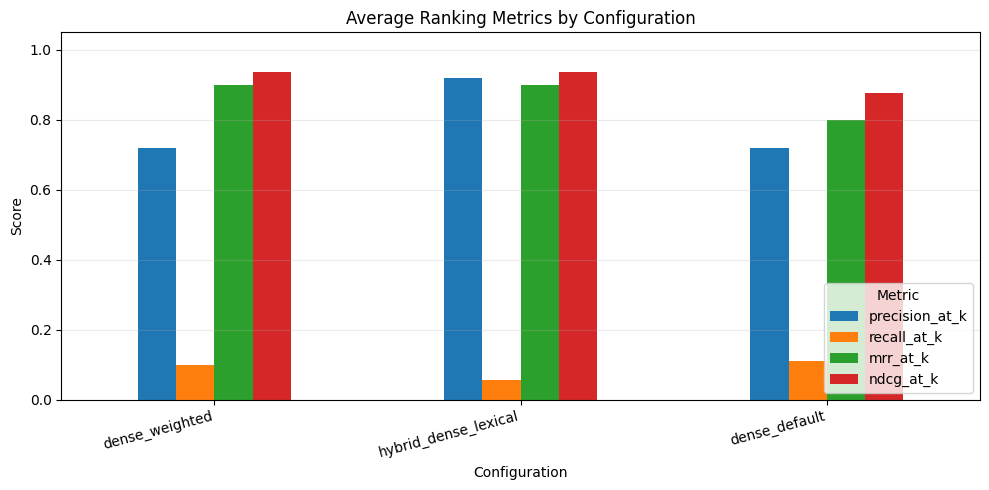

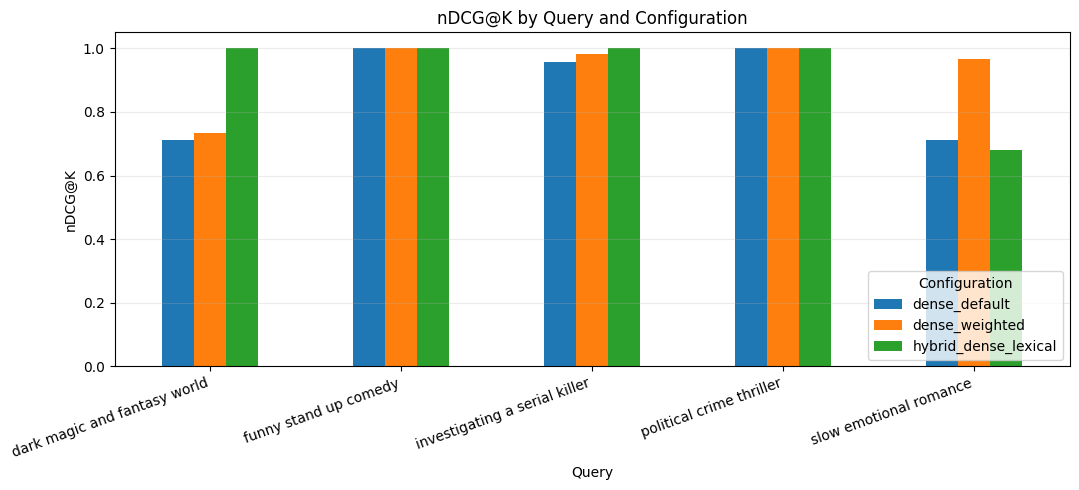

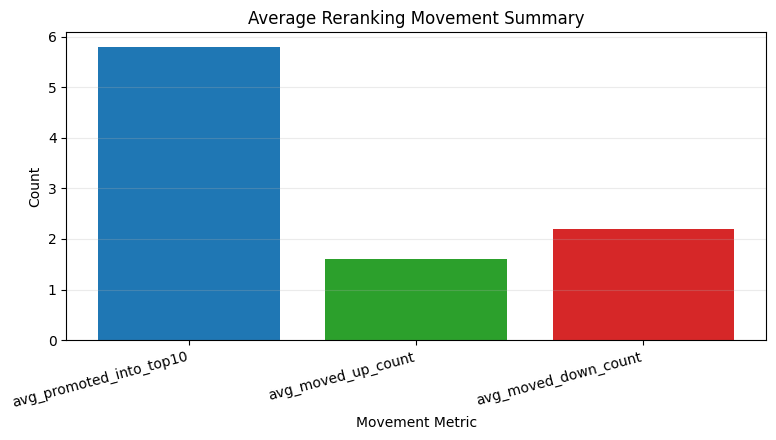

Saved figures:
- outputs\figures\step10_avg_ranking_metrics.png
- outputs\figures\step10_ndcg_by_query.png
- outputs\figures\step10_reranking_movement.png


In [22]:
# STEP 10: Visualization Dashboard
import matplotlib.pyplot as plt

# Figure 1: Average ranking metrics by configuration
plot_metrics = ["precision_at_k", "recall_at_k", "mrr_at_k", "ndcg_at_k"]
metrics_plot_df = summary_metrics.set_index("config")[plot_metrics]

fig, ax = plt.subplots(figsize=(10, 5))
metrics_plot_df.plot(kind="bar", ax=ax)
ax.set_title("Average Ranking Metrics by Configuration")
ax.set_ylabel("Score")
ax.set_xlabel("Configuration")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Metric", loc="lower right")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
fig_path_1 = OUTPUT_FIG_DIR / "step10_avg_ranking_metrics.png"
fig.savefig(fig_path_1, dpi=150, bbox_inches="tight")
plt.show()

# Figure 2: Query-level nDCG by configuration
ndcg_query_df = all_eval_metrics.pivot(index="query", columns="config", values="ndcg_at_k")

fig, ax = plt.subplots(figsize=(11, 5))
ndcg_query_df.plot(kind="bar", ax=ax)
ax.set_title("nDCG@K by Query and Configuration")
ax.set_ylabel("nDCG@K")
ax.set_xlabel("Query")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Configuration", loc="lower right")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig_path_2 = OUTPUT_FIG_DIR / "step10_ndcg_by_query.png"
fig.savefig(fig_path_2, dpi=150, bbox_inches="tight")
plt.show()

# Figure 3: Reranking movement summary
rerank_movement_df = pd.DataFrame([
    {"metric": "avg_promoted_into_top10", "value": overall_rerank_summary["avg_promoted_into_top10"]},
    {"metric": "avg_moved_up_count", "value": overall_rerank_summary["avg_moved_up_count"]},
    {"metric": "avg_moved_down_count", "value": overall_rerank_summary["avg_moved_down_count"]},
])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(rerank_movement_df["metric"], rerank_movement_df["value"], color=["#1f77b4", "#2ca02c", "#d62728"])
ax.set_title("Average Reranking Movement Summary")
ax.set_ylabel("Count")
ax.set_xlabel("Movement Metric")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
fig_path_3 = OUTPUT_FIG_DIR / "step10_reranking_movement.png"
fig.savefig(fig_path_3, dpi=150, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(f"- {fig_path_1}")
print(f"- {fig_path_2}")
print(f"- {fig_path_3}")

## Step 11 - Final Recommendation (Weighted Scoring)

Compute a weighted composite score across ranking metrics and select a default production configuration.
Result tables are saved to `outputs/recommendation`.

In [23]:
# STEP 11: Final Recommendation (Weighted Scoring)
metric_weights = {
    "ndcg_at_k": 0.40,
    "mrr_at_k": 0.30,
    "precision_at_k": 0.20,
    "recall_at_k": 0.10,
}

required_metric_cols = list(metric_weights.keys())
missing_cols = [c for c in required_metric_cols if c not in summary_metrics.columns]
if missing_cols:
    raise ValueError(f"Missing required metrics in summary_metrics: {missing_cols}")

recommendation_df = summary_metrics[["config"] + required_metric_cols].copy()
recommendation_df["weighted_score"] = 0.0

for metric_name, weight in metric_weights.items():
    recommendation_df["weighted_score"] += recommendation_df[metric_name] * weight

recommendation_df = recommendation_df.sort_values("weighted_score", ascending=False).reset_index(drop=True)
best_config = recommendation_df.iloc[0]["config"]
best_score = float(recommendation_df.iloc[0]["weighted_score"])

print("Metric weights used:")
for metric_name, weight in metric_weights.items():
    print(f"- {metric_name}: {weight}")

print("\nComposite ranking of configurations:")
display(recommendation_df)

print("\nRecommended default configuration:")
print(f"{best_config} (weighted_score={best_score:.4f})")

recommendation_path = OUTPUT_RECOMMEND_DIR / "final_config_recommendation_scores.csv"
recommendation_df.to_csv(recommendation_path, index=False)
print(f"Saved: {recommendation_path}")

Metric weights used:
- ndcg_at_k: 0.4
- mrr_at_k: 0.3
- precision_at_k: 0.2
- recall_at_k: 0.1

Composite ranking of configurations:


,config,ndcg_at_k,mrr_at_k,precision_at_k,recall_at_k,weighted_score
0,hybrid_dense_lexical,0.9359,0.9,0.92,0.0560,0.83396
1,dense_weighted,0.9366,0.9,0.72,0.0979,0.79843
2,dense_default,0.8761,0.8,0.72,0.1107,0.74551



Recommended default configuration:
hybrid_dense_lexical (weighted_score=0.8340)
Saved: outputs\recommendation\final_config_recommendation_scores.csv


## Step 12 - Weight Sensitivity Analysis

Test multiple weighting scenarios to verify whether the recommended configuration remains stable under different business priorities.
Scenario outputs are saved to `outputs/recommendation`.

In [24]:
# STEP 12: Weight Sensitivity Analysis
weight_scenarios = {
    "balanced": {
        "ndcg_at_k": 0.35,
        "mrr_at_k": 0.30,
        "precision_at_k": 0.20,
        "recall_at_k": 0.15,
    },
    "precision_first": {
        "ndcg_at_k": 0.20,
        "mrr_at_k": 0.20,
        "precision_at_k": 0.45,
        "recall_at_k": 0.15,
    },
    "ranking_quality_first": {
        "ndcg_at_k": 0.50,
        "mrr_at_k": 0.35,
        "precision_at_k": 0.10,
        "recall_at_k": 0.05,
    },
}

scenario_rows = []
scenario_detail_frames = []
for scenario_name, scenario_weights in weight_scenarios.items():
    tmp = summary_metrics[["config", "ndcg_at_k", "mrr_at_k", "precision_at_k", "recall_at_k"]].copy()
    tmp["scenario"] = scenario_name
    tmp["weighted_score"] = 0.0

    for metric_name, w in scenario_weights.items():
        tmp["weighted_score"] += tmp[metric_name] * w

    tmp = tmp.sort_values("weighted_score", ascending=False).reset_index(drop=True)
    tmp["rank_in_scenario"] = np.arange(1, len(tmp) + 1)
    scenario_detail_frames.append(tmp)

    top_row = tmp.iloc[0]
    scenario_rows.append({
        "scenario": scenario_name,
        "best_config": top_row["config"],
        "best_weighted_score": round(float(top_row["weighted_score"]), 4),
    })

scenario_best_df = pd.DataFrame(scenario_rows)
scenario_all_scores_df = pd.concat(scenario_detail_frames, ignore_index=True)

print("Best configuration per weighting scenario:")
display(scenario_best_df)

print("\nDetailed ranking by scenario:")
display(scenario_all_scores_df[[
    "scenario",
    "rank_in_scenario",
    "config",
    "weighted_score",
    "ndcg_at_k",
    "mrr_at_k",
    "precision_at_k",
    "recall_at_k",
]])

scenario_best_path = OUTPUT_RECOMMEND_DIR / "weight_sensitivity_best_config.csv"
scenario_all_scores_path = OUTPUT_RECOMMEND_DIR / "weight_sensitivity_all_scores.csv"
scenario_best_df.to_csv(scenario_best_path, index=False)
scenario_all_scores_df.to_csv(scenario_all_scores_path, index=False)
print("\nSaved:")
print(f"- {scenario_best_path}")
print(f"- {scenario_all_scores_path}")

Best configuration per weighting scenario:


,scenario,best_config,best_weighted_score
0,balanced,hybrid_dense_lexical,0.7900
1,precision_first,hybrid_dense_lexical,0.7896
2,ranking_quality_first,hybrid_dense_lexical,0.8778



Detailed ranking by scenario:


,scenario,rank_in_scenario,config,weighted_score,ndcg_at_k,mrr_at_k,precision_at_k,recall_at_k
0,balanced,1,hybrid_dense_lexical,0.789965,0.9359,0.9,0.92,0.0560
1,balanced,2,dense_weighted,0.756495,0.9366,0.9,0.72,0.0979
2,balanced,3,dense_default,0.707240,0.8761,0.8,0.72,0.1107
3,precision_first,1,hybrid_dense_lexical,0.789580,0.9359,0.9,0.92,0.0560
4,precision_first,2,dense_weighted,0.706005,0.9366,0.9,0.72,0.0979
5,precision_first,3,dense_default,0.675825,0.8761,0.8,0.72,0.1107
6,ranking_quality_first,1,hybrid_dense_lexical,0.877750,0.9359,0.9,0.92,0.0560
7,ranking_quality_first,2,dense_weighted,0.860195,0.9366,0.9,0.72,0.0979
8,ranking_quality_first,3,dense_default,0.795585,0.8761,0.8,0.72,0.1107



Saved:
- outputs\recommendation\weight_sensitivity_best_config.csv
- outputs\recommendation\weight_sensitivity_all_scores.csv


## Step 13 - Sensitivity Visualization

Visualize weighted scores and scenario winners to confirm recommendation robustness.
Figures are saved to `outputs/figures`.

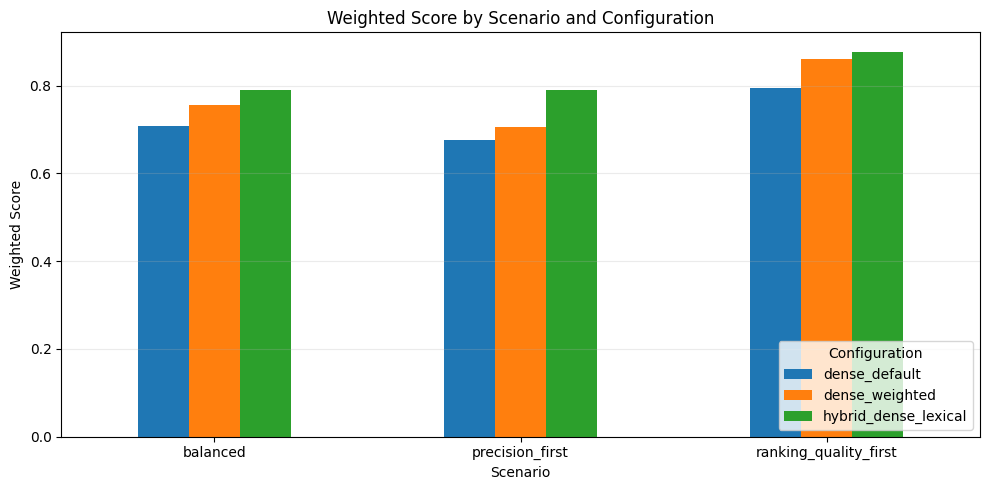

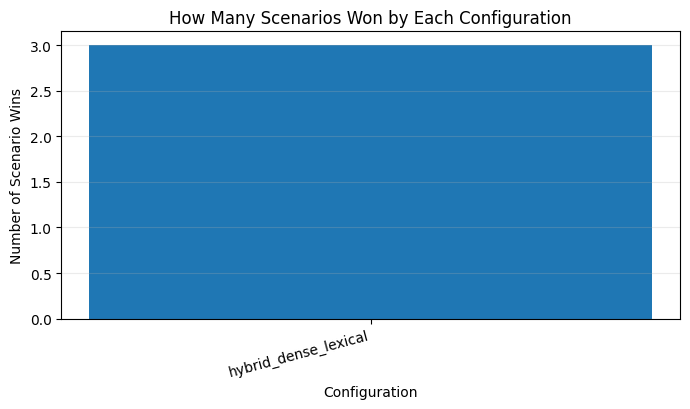

Saved figures:
- outputs\figures\step13_weighted_score_by_scenario.png
- outputs\figures\step13_scenario_wins.png


In [25]:
# STEP 13: Sensitivity Visualization
scenario_plot_df = scenario_all_scores_df.pivot(
    index="scenario",
    columns="config",
    values="weighted_score",
)

fig, ax = plt.subplots(figsize=(10, 5))
scenario_plot_df.plot(kind="bar", ax=ax)
ax.set_title("Weighted Score by Scenario and Configuration")
ax.set_xlabel("Scenario")
ax.set_ylabel("Weighted Score")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Configuration", loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
fig_path_4 = OUTPUT_FIG_DIR / "step13_weighted_score_by_scenario.png"
fig.savefig(fig_path_4, dpi=150, bbox_inches="tight")
plt.show()

winner_count_df = (
    scenario_best_df["best_config"]
    .value_counts()
    .rename_axis("config")
    .reset_index(name="wins")
)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(winner_count_df["config"], winner_count_df["wins"], color="#1f77b4")
ax.set_title("How Many Scenarios Won by Each Configuration")
ax.set_xlabel("Configuration")
ax.set_ylabel("Number of Scenario Wins")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
fig_path_5 = OUTPUT_FIG_DIR / "step13_scenario_wins.png"
fig.savefig(fig_path_5, dpi=150, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(f"- {fig_path_4}")
print(f"- {fig_path_5}")

## Step 14 - Final Conclusion and Deployment Notes

Final recommended default: `hybrid_dense_lexical`
- Best overall under weighted scoring (Step 11)
- Stable winner across sensitivity scenarios (Step 12)

Fallback option: `dense_weighted`
- Simpler pipeline while maintaining strong ranking quality

Operational notes:
- Keep artifacts in `outputs/core`, `outputs/advanced`, `outputs/recommendation`, and `outputs/figures`
- Replace proxy relevance with human labels for stronger evaluation validity